# Foreword

### This notebook
In this notebook we: 
- Download L2 data from the Solar Orbiter archive using sunpy Fido, both from HFR and TNR.
- Read files using MASER, plot the radio spectrograms, and filter noisy frequency (in a very fast way)
- Combine both spectrograms on one plot

### Previous notebook
This notebook is building on the notebook `RPW_download_and_plot_L2_spectrogram_(with_maser)`, that you may want to check for details.

### Setup
My conda environment is running with:
- Python 3.12.7
- maser-data 0.4.2
- maser-plot 0.3.3
- maser-tools 0.2.0
- maser4py 0.16.1
- sunpy 6.0.3
- sunpy-soar 1.11.1

In [1]:
import sys
print(sys.version)

3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 15:47:54) [MSC v.1941 64 bit (AMD64)]


### History
Last run on May 13 2026 by S. Musset

# Calls

In [2]:
import matplotlib.pyplot as plt
from sunpy.net import Fido, attrs as a
import sunpy_soar
from maser.data import Data
import numpy as np
import astropy.units as u
import matplotlib.dates as mdates

# Download data from SOAR

In [3]:
search_results_hfr = Fido.search(
    a.Time("2021-05-22", "2021-05-22"),
    a.Instrument.rpw,
    a.soar.Product('rpw-hfr-surv'),
    a.Level(2)
)

print(search_results_hfr)

Results from 1 Provider:

1 Results from the SOARClient:

Instrument Data product Level ...         End time        Filesize SOOP Name
                              ...                          Mbyte            
---------- ------------ ----- ... ----------------------- -------- ---------
       RPW rpw-hfr-surv    L2 ... 2021-05-23 00:00:00.000    6.649      none




In [4]:
downloaded_hfr_files = Fido.fetch(search_results_hfr)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [5]:
search_results_tnr = Fido.search(
    a.Time("2021-05-22", "2021-05-22"),
    a.Instrument.rpw,
    a.soar.Product('rpw-tnr-surv'),
    a.Level(2)
)

print(search_results_tnr)

Results from 1 Provider:

1 Results from the SOARClient:

Instrument Data product Level ...         End time        Filesize SOOP Name
                              ...                          Mbyte            
---------- ------------ ----- ... ----------------------- -------- ---------
       RPW rpw-tnr-surv    L2 ... 2021-05-23 00:00:00.000   27.073      none




In [6]:
downloaded_tnr_files = Fido.fetch(search_results_tnr)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

# Reading files using maser

### HFR

In [7]:
hfr_data = Data(downloaded_hfr_files[0]).as_xarray()

In [8]:
hfr_power = hfr_data["VOLTAGE_SPECTRAL_POWER"]
hfr_power.values = 10 * np.log10(hfr_power.values)

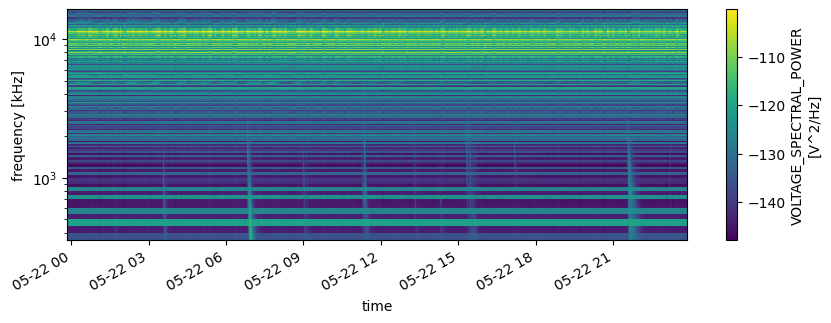

In [9]:
fig = plt.figure(figsize=(10, 3))
hfr_power.plot(yscale="log")
plt.show()

In [10]:
hfr_freq_to_filter = [hfr_power.frequency.data[i] for i in np.where(hfr_power.mean(dim='time') > -140)[0]]
filtered_hfr_power = hfr_power.drop_sel({'frequency':hfr_freq_to_filter})

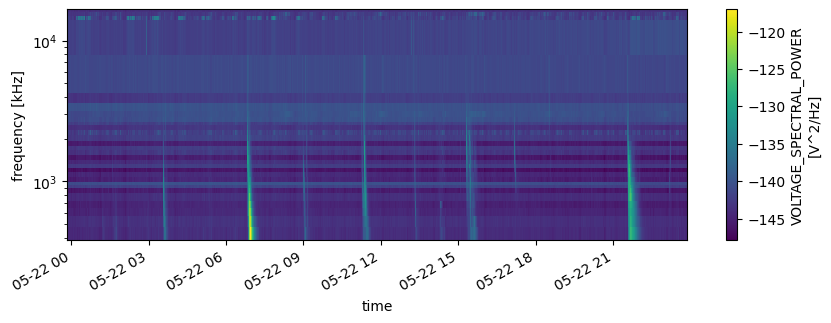

In [11]:
fig = plt.figure(figsize=(10, 3))
filtered_hfr_power.plot(yscale="log")
plt.show()

### TNR

In [12]:
tnr_data = Data(downloaded_tnr_files[0]).as_xarray()

In [13]:
tnr_power = tnr_data["VOLTAGE_SPECTRAL_POWER_CH1"]
tnr_power.values = 10 * np.log10(tnr_power.values)

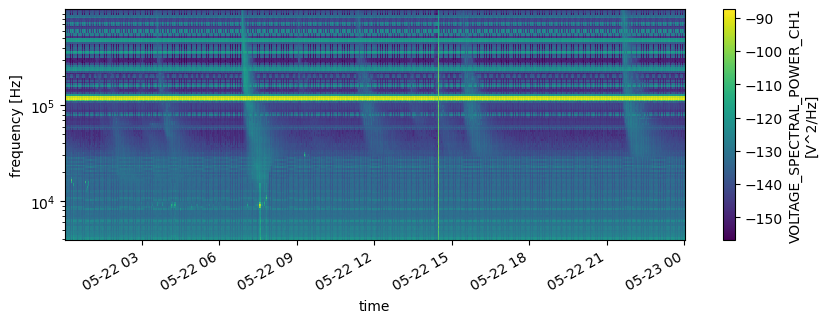

In [14]:
fig = plt.figure(figsize=(10, 3))
tnr_power.plot(yscale="log")
plt.show()

In [15]:
tnr_power["frequency"] = tnr_power["frequency"]/1e3
tnr_power["frequency"] = tnr_power.frequency.assign_attrs(units=u.kHz)

In [16]:
tnr_freq_to_filter = [tnr_power.frequency.data[i] for i in np.where(tnr_power.mean(dim='time') > -130)[0]]
filtered_tnr_power = tnr_power.drop_sel({'frequency':tnr_freq_to_filter})

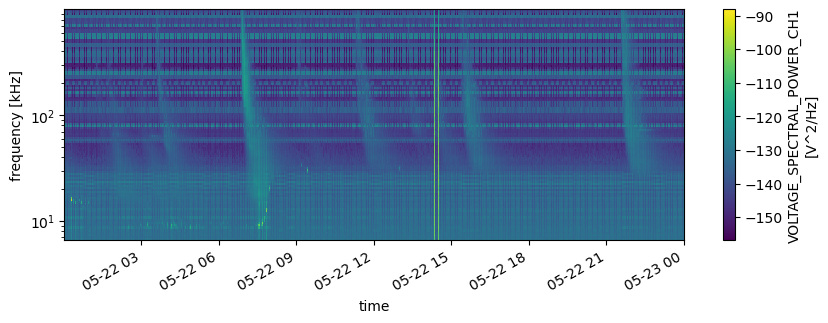

In [17]:
fig = plt.figure(figsize=(10, 3))
filtered_tnr_power.plot(yscale="log")
plt.show()

# Combined spectrogram

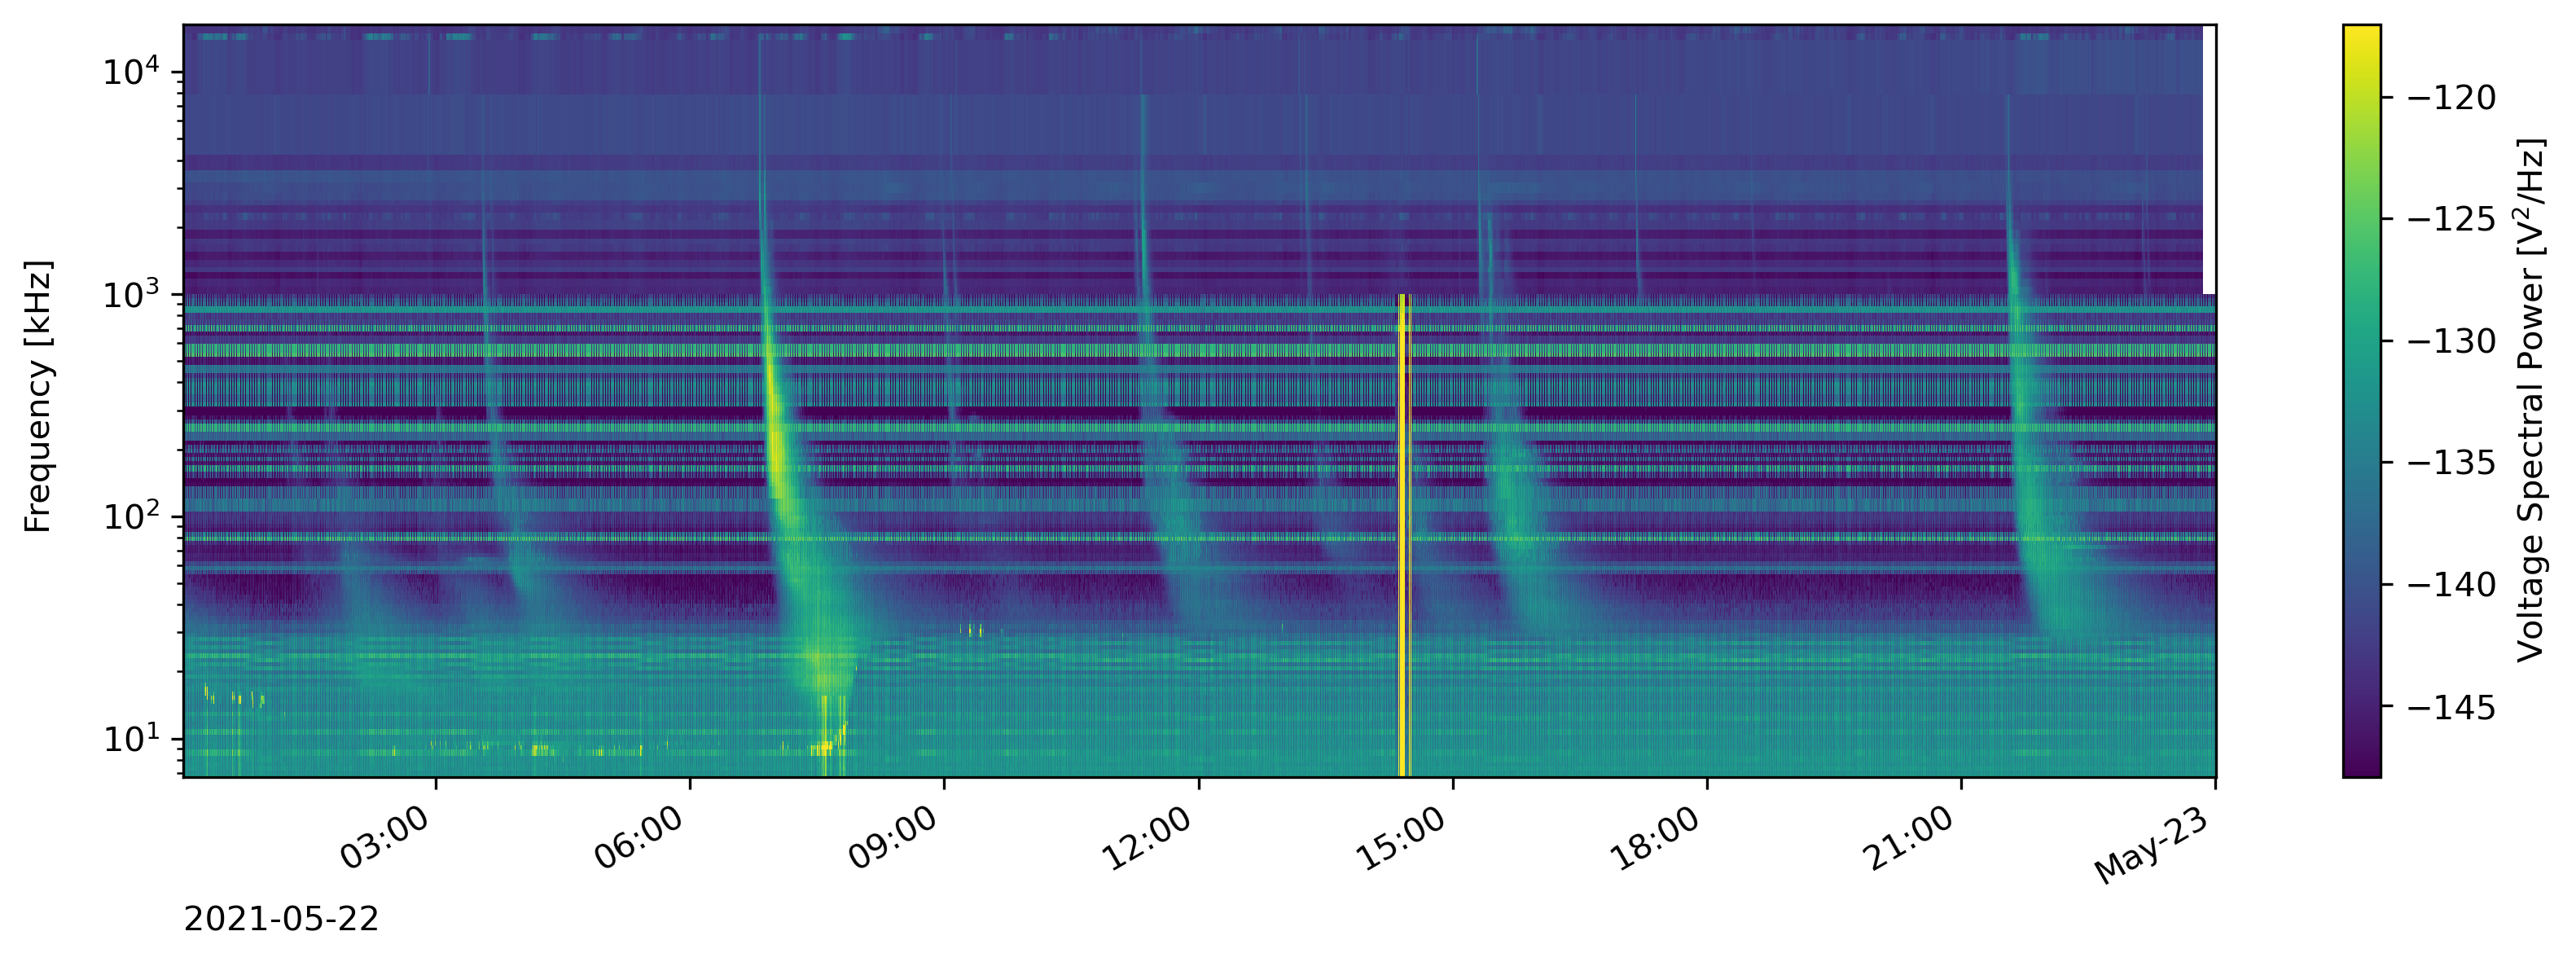

In [19]:
fig, axs = plt.subplots(nrows=1, sharex=True, sharey=False, figsize = (13, 4), dpi=300) 
# Note that modifications to the figure size or dpi will impact how some artifacts are displayed, in particular for TNR data
# maybe that indicate that we should average a big in time, or smooth the data? I don't know, and it's really a display problem 

# change the time display
locator = mdates.AutoDateLocator(minticks=3, maxticks=9)
formatter = mdates.ConciseDateFormatter(locator, show_offset=False)

a = filtered_hfr_power.plot(yscale="log", ax=axs, 
                        ylim=(np.min(filtered_tnr_power.frequency.values),np.max(filtered_hfr_power.frequency.values)),
                        vmin=filtered_hfr_power.min(), vmax=filtered_hfr_power.max(), 
                        add_colorbar=False)
b = filtered_tnr_power.plot(yscale="log", ax=axs, 
                        ylim=(np.min(filtered_tnr_power.frequency.values),np.max(filtered_hfr_power.frequency.values)),
                        vmin=filtered_hfr_power.min(), vmax=filtered_hfr_power.max(),
                        add_colorbar=False)

axs.set_ylabel('')

axs.xaxis.set_major_locator(locator)
axs.xaxis.set_major_formatter(formatter)
axs.set_xlabel(np.datetime_as_string(filtered_tnr_power.time.data[0], unit='D'), loc="left")

# Make room for the colorbar
fig.subplots_adjust(left=0.07, right=0.87)
# add the colorbar outside
cb = fig.colorbar(a)  #producing the colorbar
cb.set_label(label= 'Voltage Spectral Power [V$^2$/Hz]')

fig.supylabel('Frequency [kHz]', fontsize=10)

plt.show()